# **Experiment 3: Transformer**




Dataset: CIFAR 10
ref pytorch multihead attention docs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
save_path = '/content/drive/MyDrive/Transformer_results'
os.makedirs(save_path, exist_ok=True)

In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using:', device)

using: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)



100%|██████████| 170M/170M [00:15<00:00, 11.3MB/s]


In [ ]:
#patch embedding

# Converts image into sequence of patches
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super(PatchEmbed, self).__init__()
        # Number of patches: (32/4)^2 = 8x8 = 64 patches
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):    # Input: [B, 3, 32, 32]
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x         # Output: [B, num_patches, embed_dim]

In [ ]:
#transformer
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()
         # Multi-head self-attention
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
         # Feedforward network
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
         # Layer normalization
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # self attention with residual
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.drop(attn_out))
        # feedforward with residual
        ff_out = self.ff(x)
        x = self.norm2(x + self.drop(ff_out))
        return x


In [ ]:
class TransformerGenerator(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, depth=4, num_heads=4, ff_dim=256):
        super(TransformerGenerator, self).__init__()
        
        # Convert image to patch sequence
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        self.num_patches = self.patch_embed.num_patches
        self.patch_dim = patch_size * patch_size * in_channels

        # learnable positional encoding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim)
            for _ in range(depth)
        ])

        # output head - predict pixel values for each patch
        self.head = nn.Linear(embed_dim, self.patch_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed

        # pass thru all transformer layers
        for block in self.transformer_blocks:
            x = block(x)

        x = self.norm(x)
        x = self.head(x)
        return x

    def get_attention_maps(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed
        attn_maps = []
        for block in self.transformer_blocks:
            _, attn = block.attn(x, x, x)
            attn_maps.append(attn)
            x = block.norm1(x + block.drop(attn_maps[-1]))
            x = block.norm2(x + block.drop(block.ff(x)))
        return attn_maps

In [ ]:
#trianing
model = TransformerGenerator().to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

patch_size = 4
num_params = sum(p.numel() for p in model.parameters())
print(f'params: {num_params:,}')

losses = []
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        # make patch targets manually
        B, C, H, W = imgs.shape
        # unfold image into patches
        patches = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
        patches = patches.contiguous().view(B, C, -1, patch_size, patch_size)
        patches = patches.permute(0, 2, 1, 3, 4).contiguous()
        patches = patches.view(B, -1, C * patch_size * patch_size)  # (B, num_patches, patch_dim)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, patches)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, loss: {avg_loss:.4f}')


torch.save(model.state_dict(), os.path.join(save_path, 'transformer_model.pth'))


params: 550,832
Epoch 1/50, loss: 0.0117
Epoch 2/50, loss: 0.0010
Epoch 3/50, loss: 0.0005
Epoch 4/50, loss: 0.0004
Epoch 5/50, loss: 0.0003
Epoch 6/50, loss: 0.0002
Epoch 7/50, loss: 0.0002
Epoch 8/50, loss: 0.0001
Epoch 9/50, loss: 0.0001
Epoch 10/50, loss: 0.0001
Epoch 11/50, loss: 0.0001
Epoch 12/50, loss: 0.0001
Epoch 13/50, loss: 0.0001
Epoch 14/50, loss: 0.0000
Epoch 15/50, loss: 0.0000
Epoch 16/50, loss: 0.0000
Epoch 17/50, loss: 0.0000
Epoch 18/50, loss: 0.0000
Epoch 19/50, loss: 0.0000
Epoch 20/50, loss: 0.0000
Epoch 21/50, loss: 0.0000
Epoch 22/50, loss: 0.0000
Epoch 23/50, loss: 0.0000
Epoch 24/50, loss: 0.0000
Epoch 25/50, loss: 0.0000
Epoch 26/50, loss: 0.0000
Epoch 27/50, loss: 0.0000
Epoch 28/50, loss: 0.0000
Epoch 29/50, loss: 0.0000
Epoch 30/50, loss: 0.0000
Epoch 31/50, loss: 0.0000
Epoch 32/50, loss: 0.0000
Epoch 33/50, loss: 0.0000
Epoch 34/50, loss: 0.0000
Epoch 35/50, loss: 0.0000
Epoch 36/50, loss: 0.0000
Epoch 37/50, loss: 0.0000
Epoch 38/50, loss: 0.0000
Epoch

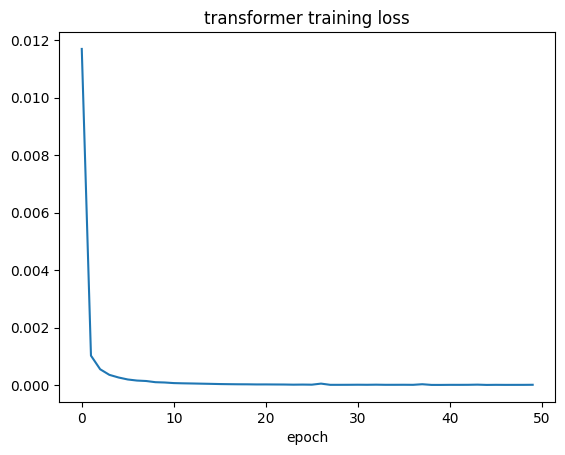

In [ ]:
plt.plot(losses)
plt.title('transformer training loss')
plt.xlabel('epoch')
plt.savefig(os.path.join(save_path, 'training_curve.png'))
plt.show()

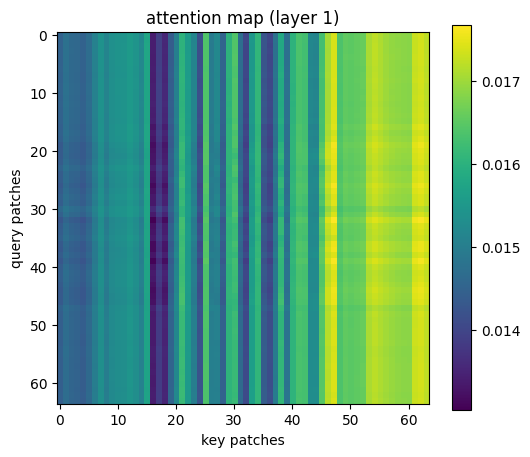

In [ ]:
# visualize attention maps
model.eval()
sample_imgs, _ = next(iter(train_loader))
sample_imgs = sample_imgs[:1].to(device)

with torch.no_grad():
    patches = model.patch_embed(sample_imgs)
    patches = patches + model.pos_embed
    x = patches

    attn_out, attn_weights = model.transformer_blocks[0].attn(x, x, x)

attn_weights = attn_weights[0].cpu().numpy()

plt.figure(figsize=(6,5))
plt.imshow(attn_weights, cmap='viridis')
plt.colorbar()
plt.title('attention map (layer 1)')
plt.xlabel('key patches')
plt.ylabel('query patches')
plt.savefig(os.path.join(save_path, 'attention_map.png'))
plt.show()


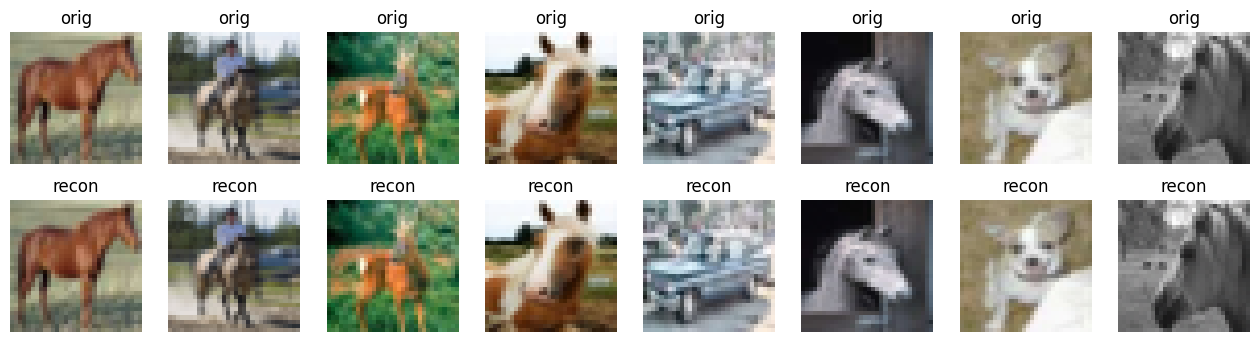

saved!


In [ ]:
model.eval()
with torch.no_grad():
    test_imgs, _ = next(iter(train_loader))
    test_imgs = test_imgs[:8].to(device)
    pred_patches = model(test_imgs)

# reshape back to images
B = pred_patches.shape[0]
p = patch_size
num_p_side = 32 // patch_size

pred_patches = pred_patches.view(B, num_p_side, num_p_side, 3, p, p)
pred_patches = pred_patches.permute(0, 3, 1, 4, 2, 5).contiguous()
recon_imgs = pred_patches.view(B, 3, 32, 32).cpu().clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(test_imgs[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title('orig')

    axes[1, i].imshow(recon_imgs[i].permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
    axes[1, i].set_title('recon')

plt.savefig(os.path.join(save_path, 'reconstructions.png'))
plt.show()

print('saved!')